# GA4 E-Commerce Funnel & Drop-Off Analysis

## Project Overview
This project analyzes user behavior across an e-commerce website to understand how users move through the purchase journey and where they drop off before completing a transaction. The goal is to identify critical friction points in the funnel and quantify their business impact in terms of potential revenue loss.

The analysis focuses on transforming raw GA4 event data into meaningful insights that help explain user behavior and support data-driven business decisions.

---

## Business Objective
The primary objectives of this analysis are to:
- Track how users progress through key stages of the e-commerce funnel
- Identify stages with the highest user drop-off
- Estimate potential revenue loss caused by user drop-offs
- Highlight high-impact areas where optimization efforts can deliver maximum business value

This project is designed to move beyond basic reporting and provide actionable insights into user behavior.

---

## Data Source
The analysis uses the GA4 Obfuscated Sample E-Commerce Dataset, a public dataset available in Google BigQuery.

The dataset contains anonymized, event-level data capturing user interactions such as:
- Page views
- Product views
- Add-to-cart actions
- Checkout initiation
- Purchase events
- Item-level pricing and quantity information

The event-based structure of GA4 enables accurate user-level funnel and behavioral analysis.

---

## Analytical Approach
The project follows a structured, end-to-end analytical workflow:

1. Funnel
   Defined a logical e-commerce funnel based on user intent:
   

2. User-Based Funnel Construction
   Built a funnel using distinct users at each stage to accurately represent real user progression and avoid repeated events.

3. Drop-Off & Conversion Analysis
   Analyzed user movement between adjacent funnel stages to identify where users stop progressing in the purchase journey.

4. Revenue Impact Estimation
   Calculated Average Order Value (AOV) and estimated potential revenue loss associated with user drop-offs at each funnel stage.

5. Visualization & Interpretation
   Used Python-based visualizations to clearly communicate funnel behavior, drop-offs, and revenue leakage.

---

## Tools & Technologies Used
- BigQuery (SQL):
  Used to query large-scale GA4 event data, construct the user-based funnel, calculate drop-offs, and estimate revenue impact.

- Python (Pandas, NumPy):  
  Used to validate SQL outputs, perform exploratory analysis, and support business-focused calculations.

- Matplotlib & Seaborn: 
  Used to visualize funnel progression, user drop-offs, and revenue leakage in a clear and interpretable format.

---

## Outcome
The analysis identifies high-impact funnel stages where user drop-off leads to significant revenue loss. These insights can be used to:
- Improve the checkout experience
- Reduce friction in the purchase journey
- Prioritize funnel optimization efforts based on business impact

This project demonstrates how GA4 event data can be transformed into actionable business insights using SQL, Python, and data visualization techniques.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [13]:
df = pd.read_csv(r"D:\data\funnel_results.csv")
df


,event_name,users,dropped_users,estimated_revenue_loss
0,page_view,269792,NaN,NaN
1,view_item,61252,208540.0,17106274.70
2,add_to_cart,12545,48707.0,3995374.13
3,begin_checkout,9715,2830.0,232141.35
4,purchase,4419,5296.0,434424.24


In [12]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event_name              5 non-null      object 
 1   users                   5 non-null      int64  
 2   dropped_users           4 non-null      float64
 3   estimated_revenue_loss  4 non-null      float64
dtypes: float64(2), int64(1), object(1)
memory usage: 292.0+ bytes


In [7]:
df.describe()

,users,dropped_users,estimated_revenue_loss
count,5.000000,4.000000,4.000000e+00
mean,71544.600000,66343.250000,5.442054e+06
std,113156.603467,97111.023547,7.965895e+06
min,4419.000000,2830.000000,2.321414e+05
25%,9715.000000,4679.500000,3.838535e+05
50%,12545.000000,27001.500000,2.214899e+06
75%,61252.000000,88665.250000,7.273099e+06
max,269792.000000,208540.000000,1.710627e+07


In [6]:
df_viz = df.copy()
df_viz[['dropped_users', 'estimated_revenue_loss']] = (
    df_viz[['dropped_users', 'estimated_revenue_loss']].fillna(0)
)
df_viz


,event_name,users,dropped_users,estimated_revenue_loss
0,page_view,269792,0.0,0.00
1,view_item,61252,208540.0,17106274.70
2,add_to_cart,12545,48707.0,3995374.13
3,begin_checkout,9715,2830.0,232141.35
4,purchase,4419,5296.0,434424.24


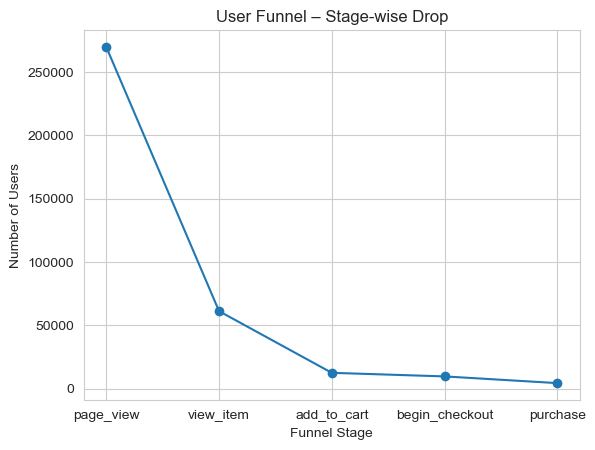

In [8]:
plt.figure()
plt.plot(df_viz['event_name'], df_viz['users'], marker='o')
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")
plt.title("User Funnel – Stage-wise Drop")
plt.show()


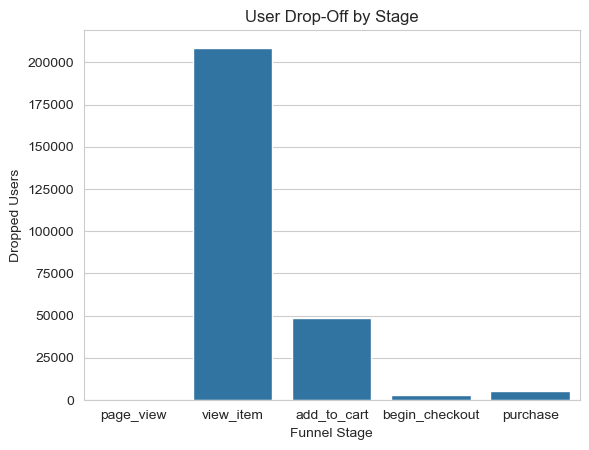

In [9]:
plt.figure()
sns.barplot(x='event_name', y='dropped_users', data=df_viz)
plt.xlabel("Funnel Stage")
plt.ylabel("Dropped Users")
plt.title("User Drop-Off by Stage")
plt.show()


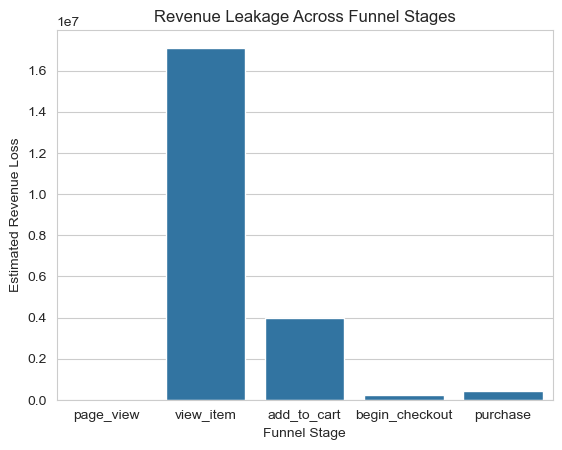

In [10]:
plt.figure()
sns.barplot(x='event_name', y='estimated_revenue_loss', data=df_viz)
plt.xlabel("Funnel Stage")
plt.ylabel("Estimated Revenue Loss")
plt.title("Revenue Leakage Across Funnel Stages")
plt.show()


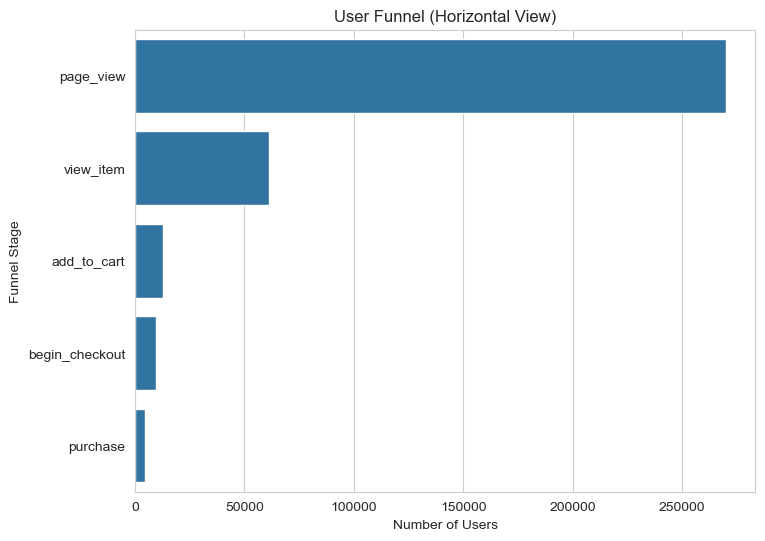

In [11]:
plt.figure(figsize=(8,6))
sns.barplot(
    x='users',
    y='event_name',
    data=df_viz.sort_values(by="users", ascending=False)
)

plt.title("User Funnel (Horizontal View)")
plt.xlabel("Number of Users")
plt.ylabel("Funnel Stage")
plt.show()